<a href="https://colab.research.google.com/github/Fariz101/Praktikum-Analisis-dan-Visualisasi-Data/blob/main/Praktikum_Analisis_Performa_Penjualan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Langkah 1: Persiapan Library & Data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data_praktikum_analisis_data.csv')
print(df.head())

   Order_ID  CustomerID  Order_Date Product_Category  Quantity  \
0      1001        5039  2023-08-19            Books         4   
1      1002        5029  2023-08-29          Fashion         5   
2      1003        5015  2023-02-21          Fashion         4   
3      1004        5043  2023-04-06          Fashion         2   
4      1005        5008  2023-08-10       Home Decor         2   

   Price_Per_Unit  Ad_Budget  Total_Sales  
0       1184000.0   982000.0    4736000.0  
1       1733000.0  3513000.0    8665000.0  
2       1767000.0  2117000.0    7068000.0  
3        512000.0  4384000.0    1024000.0  
4       1820000.0  2625000.0    3640000.0  


**Langkah 2: Inspeksi &amp; Pembersihan Data (Data Cleaning)**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143 entries, 0 to 149
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          143 non-null    int64         
 1   CustomerID        143 non-null    int64         
 2   Order_Date        143 non-null    datetime64[ns]
 3   Product_Category  143 non-null    object        
 4   Quantity          143 non-null    int64         
 5   Price_Per_Unit    143 non-null    float64       
 6   Ad_Budget         143 non-null    float64       
 7   Total_Sales       143 non-null    float64       
 8   Month             143 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 11.2+ KB


In [4]:
df.isnull().sum()

,0
Order_ID,0
CustomerID,0
Order_Date,0
Product_Category,0
Quantity,0
Price_Per_Unit,0
Ad_Budget,0
Total_Sales,7


In [5]:
df = df[df['Total_Sales'] > 0]

In [6]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

**Langkah 3: Analisis & Visualisasi**
*   Analisis Tren Penjualan Bulanan (Line Chart)

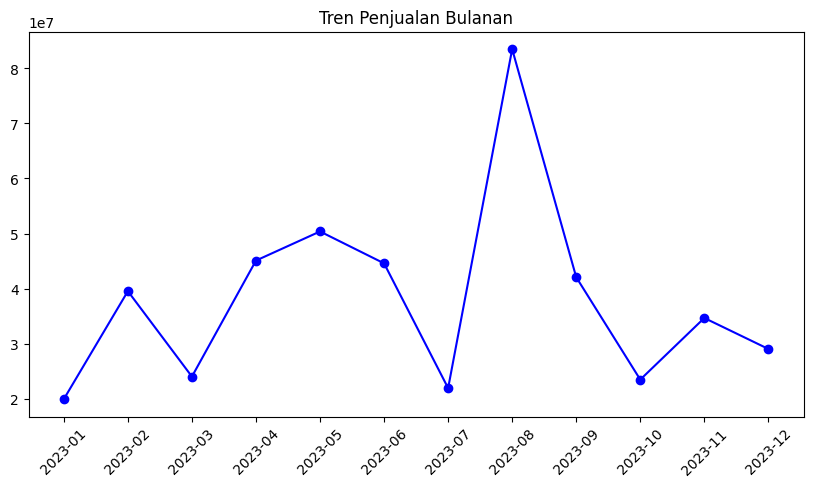

In [7]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.show()



*   Analisis Korelasi (Heatmap)



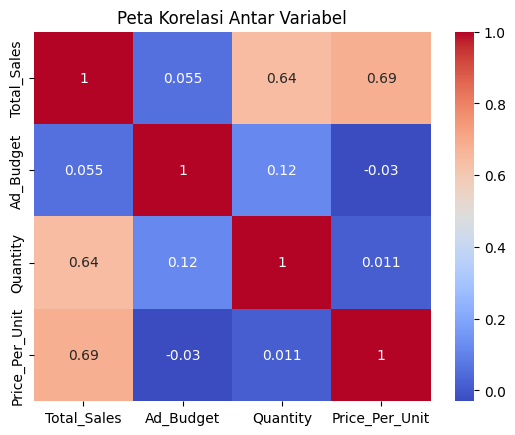

In [9]:
correlation = df[['Total_Sales', 'Ad_Budget', 'Quantity', 'Price_Per_Unit']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()

**Tugas Siswa**

1.   **Identifikasi Produk 'Underperformer'**

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

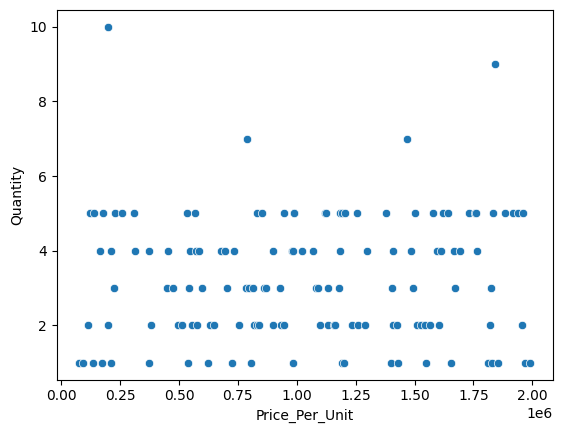

In [10]:
df_aggregated = df.groupby('Price_Per_Unit')['Quantity'].sum().reset_index()

sns.scatterplot(x='Price_Per_Unit', y='Quantity', data=df_aggregated)
plt




2.   **Segmentasi Pelanggan (RFM Analysis)**



In [15]:
import datetime as dt
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'nunique',
    'Total_Sales': 'sum'
}).reset_index()

rfm.rename(columns={
    'Order_Date': 'Recency',
    'Order_ID': 'Frequency',
    'Total_Sales': 'Monetary'
}, inplace=True)

print(rfm.head())

   CustomerID  Recency  Frequency    Monetary
0        5001      213          4   8562000.0
1        5002       77          3   6931000.0
2        5003      118          3   9433000.0
3        5004      196          2  15368000.0
4        5005       23          2   9105000.0




3.   **Analisis Kontribusi Kategori**



/tmp/ipykernel_10558/1288035069.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Efisiensi', y='Product_Category', data=df_kategori_sorted, palette='Reds_r')


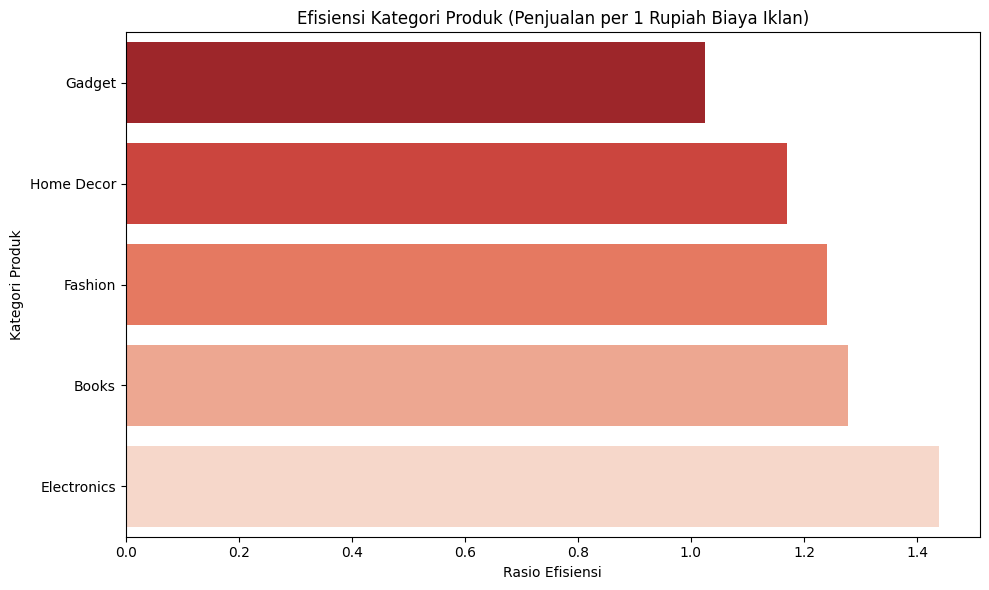

In [12]:
df_kategori = df.groupby('Product_Category')[['Total_Sales', 'Ad_Budget']].sum().reset_index()

df_kategori['Efisiensi'] = df_kategori['Total_Sales'] / df_kategori['Ad_Budget']

df_kategori_sorted = df_kategori.sort_values(by='Efisiensi', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Efisiensi', y='Product_Category', data=df_kategori_sorted, palette='Reds_r')

plt.title('Efisiensi Kategori Produk (Penjualan per 1 Rupiah Biaya Iklan)')
plt.xlabel('Rasio Efisiensi')
plt.ylabel('Kategori Produk')

plt.tight_layout()
plt.show()



4.   **Uji Hipotesis Sederhana**



In [16]:
import numpy as np

recency_batas = rfm['Recency'].median()
frequency_batas = rfm['Frequency'].median()
monetary_batas = rfm['Monetary'].median()

kondisi_loyal = (
    (rfm['Recency'] <= recency_batas) &
    (rfm['Frequency'] >= frequency_batas) &
    (rfm['Monetary'] >= monetary_batas)
)

rfm['Status_Voucher'] = np.where(kondisi_loyal, 'Berhak Dapat Voucher', 'Tidak Berhak')

print("--- Ringkasan Pembagian Kelompok ---")
print(rfm['Status_Voucher'].value_counts())

print("\n--- Pelanggan Penerima Voucher ---")
penerima_voucher = rfm[rfm['Status_Voucher'] == 'Berhak Dapat Voucher']
bukan_penerima_voucher = rfm[rfm['Status_Voucher'] == 'Tidak Berhak']
print(penerima_voucher.head())
print("\n--- Pelanggan Bukan Penerima Voucher ---")
print(bukan_penerima_voucher.head())

--- Ringkasan Pembagian Kelompok ---
Status_Voucher
Tidak Berhak            35
Berhak Dapat Voucher    13
Name: count, dtype: int64

--- Pelanggan Penerima Voucher ---
    CustomerID  Recency  Frequency    Monetary        Status_Voucher
7         5008       15          6  22350000.0  Berhak Dapat Voucher
8         5009       12          5   9334000.0  Berhak Dapat Voucher
13        5014       54          6  20797000.0  Berhak Dapat Voucher
14        5015      107          5  26309000.0  Berhak Dapat Voucher
17        5018       43          3   9556000.0  Berhak Dapat Voucher

--- Pelanggan Bukan Penerima Voucher ---
   CustomerID  Recency  Frequency    Monetary Status_Voucher
0        5001      213          4   8562000.0   Tidak Berhak
1        5002       77          3   6931000.0   Tidak Berhak
2        5003      118          3   9433000.0   Tidak Berhak
3        5004      196          2  15368000.0   Tidak Berhak
4        5005       23          2   9105000.0   Tidak Berhak




5.   **Pendalaman Teknik: RFM Analysis**



In [18]:

# Asumsi 'Snapshot_Date'; adalah hari esok dari tanggal transaksi terakhir di data
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
'Order_Date': lambda x: (snapshot_date - x.max()).days, # Recency
'Order_ID': 'count', # Frequency
'Total_Sales': 'sum' # Monetary
})
# Rename kolom agar mudah dibaca
rfm.columns = ['Recency', 'Frequency', 'Monetary']
# Memberikan skor 1-5 (Semakin tinggi semakin baik)

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]) # Recency kecil = Skor besar
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])
# Gabungkan skor menjadi satu segmen
rfm['RFM_Group'] = rfm.R_Score.astype(str) + rfm.F_Score.astype(str) + rfm.M_Score.astype(str)



6.   **Pendalaman Teknik: Regresi Linear Sederhana**



In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df[['Ad_Budget']] # Fitur
y = df['Total_Sales'] # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Koefisien Iklan: {model.coef_[0]}")
print(f"Akurasi Model (R2 Score): {model.score(X_test, y_test)}")

Koefisien Iklan: 0.1841982749623798
Akurasi Model (R2 Score): -0.1956467472142791
